In [2]:
from py_utils import catalog_methods
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


/mnt/g/My Drive/Projects/py_utils/py_utils/catalog_analysis.py:9: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy import stats


In [5]:
# output_folder = os.path.join(os.getcwd(), 'output_data/')
# first_file = next(os.walk(output_folder))[2][0]
# file_path = os.path.join(output_folder, first_file)

input_folder = os.path.join(os.getcwd(), 'input_data/')
# input_file = 'example_catalog.csv'
# input_file = 'example_catalog_mc_var.csv'
# input_file = 'catalogs/converted_nz_geonet.csv'
input_file = 'catalogs/converted_jma.csv'
file_path = os.path.join(input_folder, input_file)


In [3]:
catalog = pd.read_csv(file_path)
catalog.head(1000)


,id,latitude,longitude,time,magnitude
0,1,41.703333,144.503167,1919-01-04 09:20:25.880000,5.2
1,2,35.262500,140.341833,1919-01-10 16:59:50.210000,4.0
2,3,35.372833,137.888833,1919-01-12 13:20:47.240000,5.1
3,4,29.215500,142.492500,1919-01-22 15:44:35.019999,4.6
4,5,36.635333,140.822500,1919-01-22 19:28:05.569999,3.7
...,...,...,...,...,...
995,996,29.242667,130.135500,1923-11-03 16:19:30.900000,6.7
996,997,36.705833,141.053333,1923-11-04 18:36:42.150000,5.2
997,998,35.597333,140.843167,1923-11-04 18:56:31.829999,3.7
998,999,35.690667,139.516500,1923-11-04 20:45:41.730000,6.3


In [4]:
# # add 180 to negative longitudes
# longitudes = catalog.longitude.values
# longitudes[longitudes<0]  = longitudes[longitudes<0] + 360
# catalog.longitude = longitudes


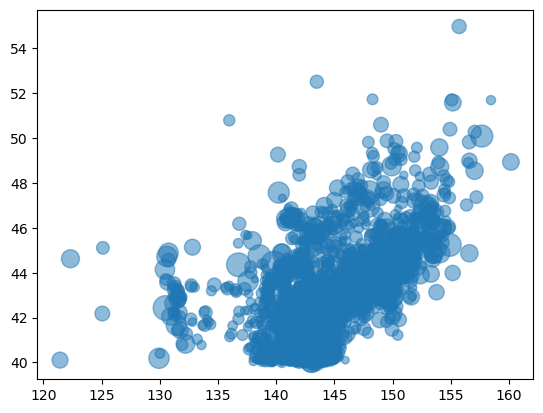

In [5]:
f_spatial, ax_spatial = plt.subplots()
lat_logical = catalog.latitude.values>=40
cropped_catalog = catalog.iloc[lat_logical, :]
ax_spatial.scatter(cropped_catalog.head(10000)['longitude'], cropped_catalog.head(10000)['latitude'], s=2.2**cropped_catalog.head(10000)['magnitude'], alpha=0.5)


In [6]:
north_japan_rectangle = np.array([
    [40, 137],
    [48, 137],
    [48, 155],
    [40, 155],
    [40, 137],
])
# save as .npy file
np.save(os.path.join(input_folder, 'north_japan_rect.npy'), north_japan_rectangle)


In [6]:
# # save new df to csv
# output_file = 'catalogs/converted_nz_geonet_shifted.csv'
# file_path = os.path.join(input_folder, output_file)
# cropped_catalog.head(10000).to_csv(file_path)


In [7]:
cropped_catalog.tail(30).time


4629334    2023-03-31 00:41:47.910000
4629337    2023-03-31 00:46:21.359999
4629338    2023-03-31 00:46:55.089999
4629352    2023-03-31 01:23:31.130000
4629357    2023-03-31 01:41:39.690000
4629362    2023-03-31 01:57:19.349999
4629365    2023-03-31 02:00:20.130000
4629370    2023-03-31 02:06:32.150000
4629409    2023-03-31 03:35:47.779999
4629410    2023-03-31 03:39:39.779999
4629429    2023-03-31 04:42:08.420000
4629431    2023-03-31 04:45:25.980000
4629435    2023-03-31 05:00:14.589999
4629443    2023-03-31 05:28:14.029999
4629453    2023-03-31 06:22:24.890000
4629464    2023-03-31 07:01:01.160000
4629483    2023-03-31 07:48:40.329999
4629488    2023-03-31 07:59:06.220000
4629558    2023-03-31 10:41:04.730000
4629563    2023-03-31 10:47:14.430000
4629565    2023-03-31 10:48:56.279999
4629566    2023-03-31 10:49:00.089999
4629568    2023-03-31 10:59:55.769999
4629572    2023-03-31 11:11:59.640000
4629574    2023-03-31 11:14:09.670000
4629604    2023-03-31 12:13:36.190000
4629615    2

In [17]:
# select 10000 random events from cropped_catalog using np.random.choice
rand_indexes = np.random.choice(cropped_catalog.index, size=10000, replace=False)
random_catalog = cropped_catalog.loc[rand_indexes]
random_catalog = random_catalog.sort_values(by=['time'])


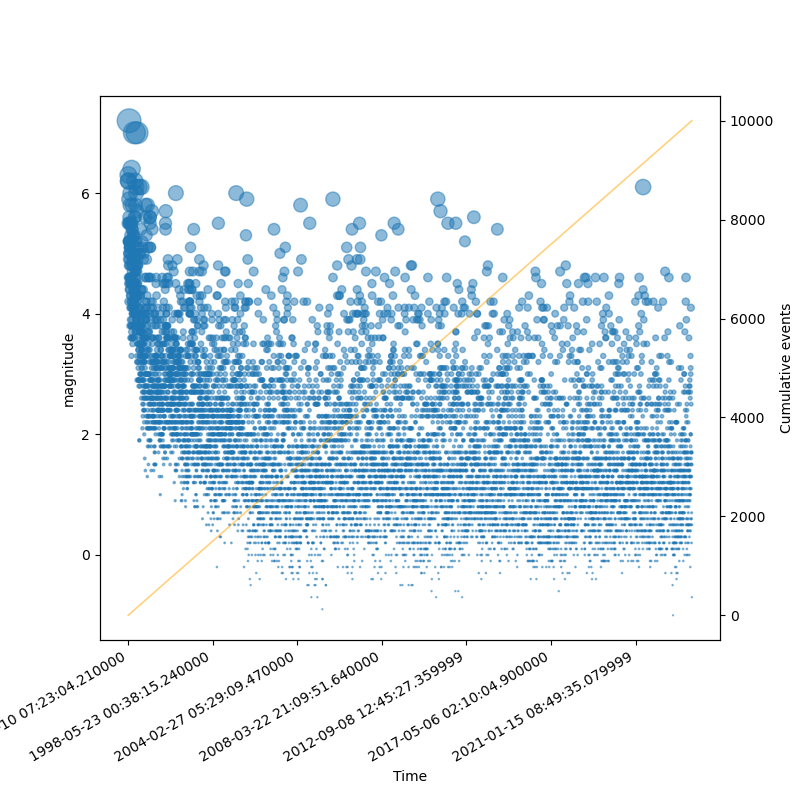

In [18]:
%matplotlib widget
from matplotlib.ticker import MaxNLocator
from matplotlib.dates import DateFormatter

# random_catalog['time'] = pd.to_datetime(random_catalog['time'])

f_time_series, ax_time_series = plt.subplots(figsize=(8, 8))
np.random.randint
random_catalog.catalog_tools.plot_time_series('magnitude', completeness=np.nan, ax=ax_time_series)
ax_time_series.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax_time_series.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
# labels = ax_time_series.get_xticklabels()
# plt.setp(labels, rotation=45, horizontalalignment='right')
f_time_series.autofmt_xdate()


In [ ]:
output_folder = os.path.join(os.getcwd(), 'output_data/')
output_file = 'simulated_catalog_continuation.csv'
file_path = os.path.join(output_folder, output_file)
catalog_continuation = pd.read_csv(file_path)


In [ ]:
catalog_continuation


,id,latitude,longitude,magnitude,time
0,3305,34.267862,-119.624258,3.9,2007-01-14 20:20:59.969159000
1,3306,36.613851,-119.854002,3.8,2007-01-20 12:43:39.053286000
2,3307,41.066503,-122.454900,3.7,2007-01-21 04:35:42.369799000
3,3308,37.600557,-117.555641,3.8,2007-02-18 23:51:57.030534000
4,3309,34.395704,-117.372478,3.6,2007-03-09 12:36:05.031923000
...,...,...,...,...,...
888,4196,41.030147,-124.597739,4.7,2016-10-18 01:32:18.238085741
889,4197,41.201606,-124.598553,3.6,2016-12-01 09:38:31.935607243
890,4198,41.030653,-124.585439,3.9,2016-10-18 05:40:23.333551304
891,4199,41.037563,-124.597247,3.6,2016-10-26 07:09:30.687064561


In [ ]:
ax_spatial.scatter(catalog_continuation['longitude'], catalog_continuation['latitude'], c='r', s=2.2**catalog_continuation['magnitude'], alpha=0.5)


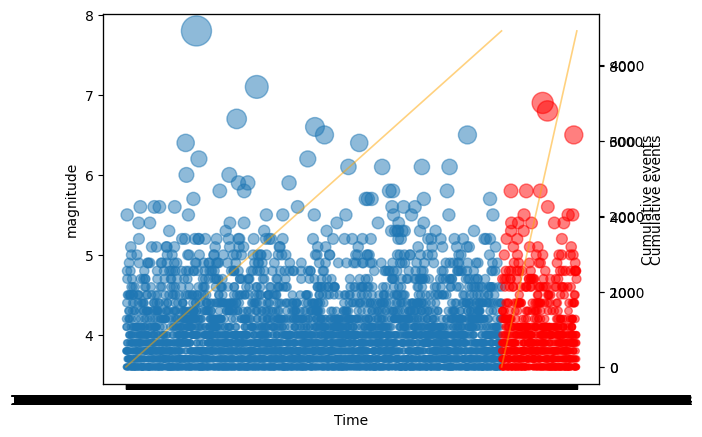

In [ ]:
catalog_continuation.catalog_tools.plot_time_series('magnitude', completeness=np.nan, ax=ax_time_series, c='r')
f_time_series


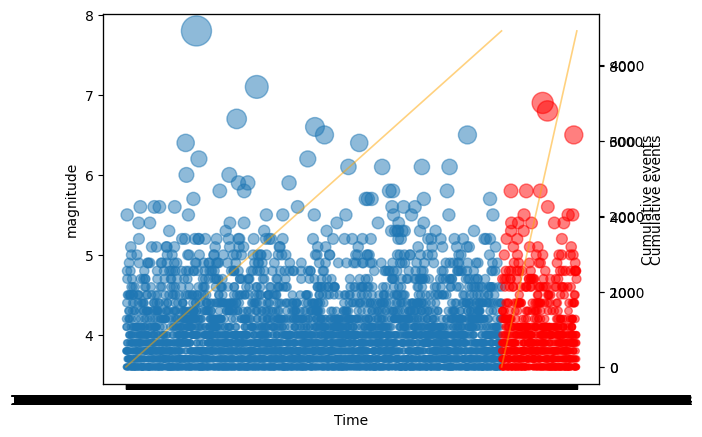

In [ ]:
%matplotlib widget
f_time_series


In [ ]:
catalog.sort_values('time')


,id,latitude,longitude,time,magnitude
0,1065,37.725523,-118.455907,1971-01-02 20:23:51.985259000,3.8
1,1066,37.613990,-117.181949,1971-01-05 10:06:37.827212000,4.2
2041,5758,36.649046,-114.791831,1971-01-06 01:20:23.580918000,4.2
2434,6509,42.111072,-118.701570,1971-02-25 11:24:47.962124800,3.8
3255,8113,32.228058,-113.514014,1971-02-28 02:21:35.531699799,4.4
...,...,...,...,...,...
3658,8852,32.160837,-117.655027,2020-12-15 06:13:27.342446400,4.1
3463,8482,32.110714,-117.467247,2020-12-16 16:10:08.818516800,4.1
3657,8851,32.110708,-117.450863,2020-12-17 13:09:32.010561600,3.8
3961,9419,38.025073,-120.030247,2020-12-23 01:28:22.989432800,4.2


,id,latitude,longitude,time,magnitude
0,1065,37.725523,-118.455907,1971-01-02 20:23:51.985259000,3.8
1,1066,37.613990,-117.181949,1971-01-05 10:06:37.827212000,4.2
2041,5758,36.649046,-114.791831,1971-01-06 01:20:23.580918000,4.2
2434,6509,42.111072,-118.701570,1971-02-25 11:24:47.962124800,3.8
3255,8113,32.228058,-113.514014,1971-02-28 02:21:35.531699799,4.4
...,...,...,...,...,...
3658,8852,32.160837,-117.655027,2020-12-15 06:13:27.342446400,4.1
3463,8482,32.110714,-117.467247,2020-12-16 16:10:08.818516800,4.1
3657,8851,32.110708,-117.450863,2020-12-17 13:09:32.010561600,3.8
3961,9419,38.025073,-120.030247,2020-12-23 01:28:22.989432800,4.2


In [ ]:
catalog_continuation.sort_values('time')


,id,latitude,longitude,magnitude,time
317,3625,35.633080,-115.548568,3.9,2007-01-01 03:24:39.911036195
295,3603,41.264498,-119.803934,4.6,2007-01-02 05:24:09.436598552
326,3634,35.758570,-115.392281,4.7,2007-01-02 22:43:47.235264773
0,3305,34.267862,-119.624258,3.9,2007-01-14 20:20:59.969159000
135,3440,34.246966,-119.621515,3.7,2007-01-14 20:22:19.601386122
...,...,...,...,...,...
130,3435,42.049849,-124.045989,3.6,2016-12-07 20:03:00.795076000
131,3436,42.966978,-122.255478,3.9,2016-12-13 00:02:36.101591000
596,3904,35.853229,-114.827405,3.7,2016-12-20 03:13:05.843029202
132,3437,32.553924,-113.875355,3.9,2016-12-24 20:01:29.901778000
